# Predicting T-shirt size using the ANSUR II dataset
We will here try to predict a persons t-shirt size given the weight and height of the person. We will use the ANSUR II dataset which contains a lot of information about the physical attributes of a large number of people.
 
We will first try to map the persons in the dataset to a t-shirt size. It is hard to find a concise size chart for t-shirt so we will create our own, initial chart, based on these assumptions:
 
We will only look at two measurements, Shoulder Width and Chest Circumference.
 
Our first problem is that Shoulder Width is not one of the measurements taken in the dataset. But we have Biacromial Breadth which is the distance between the two acromion processes. We will assume that this is the same as Shoulder Width.
 
We will then have these initial rules:
 
| Size | Percentile |
|------|------------|
| XS   | 0-5        |
| S    | 5-25       |
| M    | 25-50      |
| L    | 50-75      |
| XL   | 75-90      |
| XXL  | 90-97      |
| XXXL | 97-100     |

# Lab 3

Earlier in the project, we mentioned that there might be conflicts when comparing sizes based on different measurements (e.g., chest circumference and shoulder breadth). For instance, a person might have size S for chest but size M for shoulders. Your task is to get a clearer picture of how many individuals have matching sizes for both measurements and how many have different sizes (i.e., they fall into different sizes for shoulder breadth and chest circumference).
 
Use the size chart: Use a size chart that specifies the limits for shoulder breadth and chest circumference for each size.
 
Create a function: Write a function that iterates through each person's measurements and compares them with the size chart.
 
Count matches and conflicts: The function should count the number of individuals who have exactly one matching size and the number of individuals who have multiple possible sizes (conflicts).
 
Test your function with both female and male datasets, and use appropriate size charts for each gender.

## Inspect the data

In [173]:
import pandas as pd
import numpy as np


In [174]:
female = pd.read_csv('./data/female.csv')
male = pd.read_csv('./data/male.csv')

In [175]:
print(f'For women we have (rows, columns) {female.shape}')
print(f'For men we have (rows, columns) {male.shape}')

For women we have (rows, columns) (1986, 108)
For men we have (rows, columns) (4082, 108)


## Checking the percentiles

In [176]:
def compute_percentile_ranges(column):
    # Define percentile ranges
    ranges = [(0,5), (5,25), (25,50), (50,75), (75,90), (90,97), (97,100)]
    
    percentiles = {(low, high): (column.quantile(low/100), column.quantile(high/100)) for low, high in ranges}
    
    counts = {}
    
    # range and values make up each items
    for r, (low, high) in percentiles.items():
        counts[r] = int(((column >= low) & (column < high)).sum())
        
    return counts
        
        
print(compute_percentile_ranges(female['chestcircumference']))
print(compute_percentile_ranges(female['biacromialbreadth']))

{(0, 5): 100, (5, 25): 396, (25, 50): 492, (50, 75): 499, (75, 90): 299, (90, 97): 140, (97, 100): 59}
{(0, 5): 93, (5, 25): 377, (25, 50): 477, (50, 75): 541, (75, 90): 297, (90, 97): 139, (97, 100): 61}


In [177]:

print(compute_percentile_ranges(male['chestcircumference']))
print(compute_percentile_ranges(male['biacromialbreadth']))

{(0, 5): 199, (5, 25): 810, (25, 50): 1025, (50, 75): 1012, (75, 90): 616, (90, 97): 295, (97, 100): 124}
{(0, 5): 191, (5, 25): 787, (25, 50): 989, (50, 75): 1079, (75, 90): 610, (90, 97): 303, (97, 100): 122}


## Generate the t-shirt size chart

In [178]:
def compute_size_percentile_measurements(data, chest_column, shoulder_column):
    sizes = ['XS', 'S', 'M', 'L', 'XL', '2XL', '3XL']
    ranges = [0, 5, 25, 50, 75, 90, 97]  # lowest percentile value for each
    
    # Compute the values for each percentile for chest and shoulder
    chest_percentiles = {p: data[chest_column].quantile(p/100) for p in ranges}
    shoulder_percentiles = {p: data[shoulder_column].quantile(p/100) for p in ranges}
    
    # Map the t-shirt sizes to the corresponding chest and shoulder measurements
    size_mappings = {}
    for i, size in enumerate(sizes):
        size_mappings[size] = {
            'Chest': int(chest_percentiles[ranges[i]]),
            'Shoulder': int(shoulder_percentiles[ranges[i]])
        }
    return size_mappings
    
print(compute_size_percentile_measurements(female, 'chestcircumference', 'biacromialbreadth'))
print(compute_size_percentile_measurements(male, 'chestcircumference', 'biacromialbreadth'))
    

{'XS': {'Chest': 695, 'Shoulder': 283}, 'S': {'Chest': 824, 'Shoulder': 335}, 'M': {'Chest': 889, 'Shoulder': 353}, 'L': {'Chest': 940, 'Shoulder': 365}, 'XL': {'Chest': 999, 'Shoulder': 378}, '2XL': {'Chest': 1057, 'Shoulder': 389}, '3XL': {'Chest': 1117, 'Shoulder': 400}}
{'XS': {'Chest': 774, 'Shoulder': 337}, 'S': {'Chest': 922, 'Shoulder': 384}, 'M': {'Chest': 996, 'Shoulder': 403}, 'L': {'Chest': 1056, 'Shoulder': 415}, 'XL': {'Chest': 1117, 'Shoulder': 428}, '2XL': {'Chest': 1172, 'Shoulder': 441}, '3XL': {'Chest': 1233, 'Shoulder': 452}}


In [179]:
female_sizes = {
    'XS': {'Chest': 695, 'Shoulder': 283}, 
    'S': {'Chest': 824, 'Shoulder': 335}, 
    'M': {'Chest': 889, 'Shoulder': 353}, 
    'L': {'Chest': 940, 'Shoulder': 365}, 
    'XL': {'Chest': 999, 'Shoulder': 378}, 
    '2XL': {'Chest': 1057, 'Shoulder': 389}, 
    '3XL': {'Chest': 1117, 'Shoulder': 400}
}
male_sizes = {
    'XS': {'Chest': 774, 'Shoulder': 337}, 
    'S': {'Chest': 922, 'Shoulder': 384}, 
    'M': {'Chest': 996, 'Shoulder': 403}, 
    'L': {'Chest': 1056, 'Shoulder': 415}, 
    'XL': {'Chest': 1117, 'Shoulder': 428}, 
    '2XL': {'Chest': 1172, 'Shoulder': 441}, 
    '3XL': {'Chest': 1233, 'Shoulder': 452}
}

# Lab 3

Earlier in the project, we mentioned that there might be conflicts when comparing sizes based on different measurements (e.g., chest circumference and shoulder breadth). For instance, a person might have size S for chest but size M for shoulders. Your task is to get a clearer picture of how many individuals have matching sizes for both measurements and how many have different sizes (i.e., they fall into different sizes for shoulder breadth and chest circumference).
 
Use the size chart: Use a size chart that specifies the limits for shoulder breadth and chest circumference for each size.
 
Create a function: Write a function that iterates through each person's measurements and compares them with the size chart.
 
Count matches and conflicts: The function should count the number of individuals who have exactly one matching size and the number of individuals who have multiple possible sizes (conflicts).
 
Test your function with both female and male datasets, and use appropriate size charts for each gender.

In [180]:
def comparison(gender, chest_value, shoulder_value):
    sizes = female_sizes if gender == 'female' else male_sizes
    size_order = ['3XL', '2XL', 'XL', 'L', 'M', 'S']    
    
    chestsize = 'XS'
    for size in size_order:
        if chest_value >= sizes[size]['Chest']:
            chestsize = size
            break
        
    shouldersize = 'XS'
    for size in size_order:
        if shoulder_value >= sizes[size]['Shoulder']:
            shouldersize = size
            break

    return 'match' if chestsize == shouldersize else 'conflict'
            
    
female_results = female.apply(lambda individual: comparison('female', individual['chestcircumference'], individual['biacromialbreadth']), axis=1)

male_results = male.apply(lambda individual: comparison('male', individual['chestcircumference'], individual['biacromialbreadth']), axis=1)

print(f'Female - Matches: {(female_results == 'match').sum()}, Conflicts: {(female_results == 'conflict').sum()}')
print(f'Male - Matches: {(male_results == 'match').sum()}, Conflicts: {(male_results == 'conflict').sum()}')
    

Female - Matches: 474, Conflicts: 1512
Male - Matches: 1177, Conflicts: 2905


Add column for recommended t-shirt size.

In [181]:
def get_size(gender, chest_value, shoulder_value):
    sizes = female_sizes if gender == 'female' else male_sizes
    size_order = ['3XL', '2XL', 'XL', 'L', 'M', 'S']    
    
    chestsize = 'XS'
    for size in size_order:
        if chest_value >= sizes[size]['Chest']:
            chestsize = size
            break
        
    shouldersize = 'XS'
    for size in size_order:
        if shoulder_value >= sizes[size]['Shoulder']:
            shouldersize = size
            break
    
    recommended_size = 'XS'
    for size in size_order:
        if chestsize == size or shouldersize == size:
            recommended_size = size
            break
    
    return recommended_size

female['tshirtsize'] = female.apply(lambda individual: get_size('female', individual['chestcircumference'], individual['biacromialbreadth']), axis=1)

male['tshirtsize'] = male.apply(lambda individual: get_size('male', individual['chestcircumference'], individual['biacromialbreadth']), axis=1)

save in new file

In [182]:
female.to_csv('./data/female_recommended_tshirt_size.csv')
male.to_csv('./data/male_recommended_tshirt_size.csv')

get data from new file

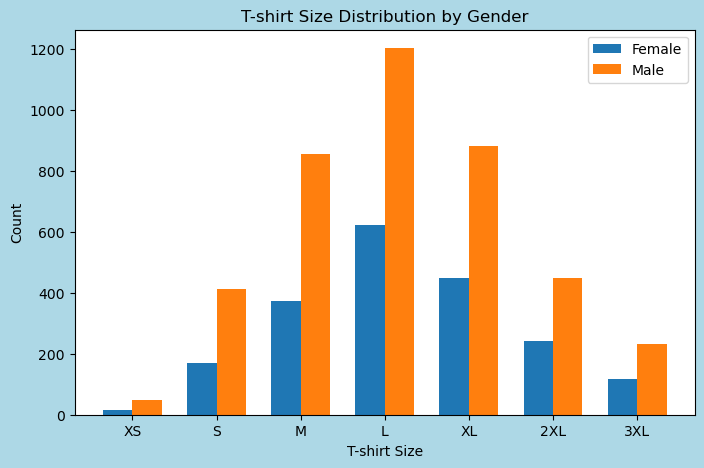

In [195]:
import matplotlib.pyplot as plt
import numpy as np

new_female = pd.read_csv('./data/female_recommended_tshirt_size.csv')
new_male = pd.read_csv('./data/male_recommended_tshirt_size.csv')

size_order = ['XS', 'S', 'M', 'L', 'XL', '2XL', '3XL'] 

female_counts = new_female['tshirtsize'].value_counts().reindex(size_order, fill_value= 0)

male_counts = new_male['tshirtsize'].value_counts().reindex(size_order, fill_value= 0)

x = np.arange(len(size_order))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
fbars = ax.bar(x - width/2, female_counts, width, label='Female')
mbars = ax.bar(x + width/2, male_counts, width, label='Male')

fig.set_facecolor('lightblue')
ax.set_xlabel('T-shirt Size')
ax.set_ylabel('Count')
ax.set_title('T-shirt Size Distribution by Gender')
ax.set_xticks(x)
ax.set_xticklabels(size_order)
ax.legend()

plt.show()


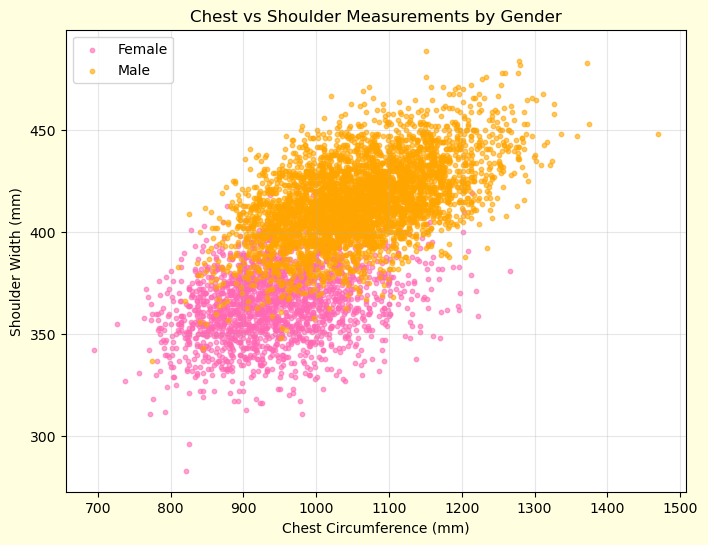

In [194]:
fig, ax = plt.subplots(figsize=(8, 6))

fig.set_facecolor('lightyellow')
ax.scatter(female['chestcircumference'], female['biacromialbreadth'], alpha=0.6, color='hotpink', label='Female', s=10)
ax.scatter(male['chestcircumference'], male['biacromialbreadth'], alpha=0.6, color='orange', label='Male', s=10)

ax.set_xlabel('Chest Circumference (mm)')
ax.set_ylabel('Shoulder Width (mm)')
ax.set_title('Chest vs Shoulder Measurements by Gender')
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()